In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Training data
X_train = np.random.randn(100, 5)
true_w = np.random.randn(5)
true_b = np.random.randn()
z_train = np.dot(X_train, true_w) + true_b
prob_train = 1 / (1 + np.exp(-z_train))
y_train = (prob_train > 0.5).astype(int)

# Testing data
X_test = np.random.randn(10, 5)
z_test = np.dot(X_test, true_w) + true_b
prob_test = 1 / (1 + np.exp(-z_test))
y_test = (prob_test > 0.5).astype(int)

In [ ]:
# Initialize weights
w = np.zeros(5)
b = 0.0

# Hyperparameters
lr = 0.1
Epochs = 10

n = len(X_train)
losses = []

print("Initial weights:", w)
print("Initial bias:", b)

Initial weights: [0. 0. 0. 0. 0.]
Initial bias: 0.0


In [ ]:
# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Training loop
for e in range(Epochs):

    # Forward pass
    y_p = sigmoid(np.dot(X_train, w) + b)

    # Loss (Binary Cross-Entropy)
    loss = -np.mean(y_train * np.log(y_p + 1e-7) + (1 - y_train) * np.log(1 - y_p + 1e-7))
    losses.append(loss)

    # Gradients
    dw = (1/n) * np.dot(X_train.T, (y_p - y_train))
    db = (1/n) * np.sum(y_p - y_train)

    # Update weights
    w = w - (lr * dw)
    b = b - (lr * db)

    print(f"Epoch {e+1}, Loss: {loss:.6f}")

Epoch 1, Loss: 0.693147
Epoch 2, Loss: 0.680595
Epoch 3, Loss: 0.668542
Epoch 4, Loss: 0.656967
Epoch 5, Loss: 0.645848
Epoch 6, Loss: 0.635165
Epoch 7, Loss: 0.624898
Epoch 8, Loss: 0.615026
Epoch 9, Loss: 0.605532
Epoch 10, Loss: 0.596398


In [ ]:
# Final weights
print("Final weights:", w)
print("Final bias:", b)

Final weights: [ 0.07107522  0.22192754 -0.20508061  0.04329346 -0.07976958]
Final bias: -0.04031423521035302


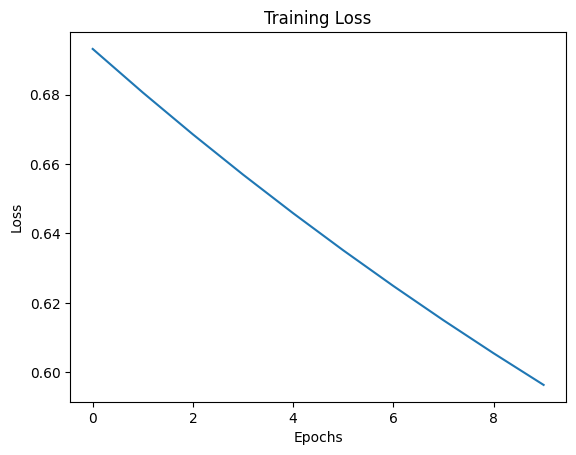

In [ ]:
# Plot loss
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [ ]:
# Testing predictions
y_pred = (sigmoid(np.dot(X_test, w) + b) >= 0.5).astype(int)

print("Predictions:", y_pred)
print("Actual:", y_test)

Predictions: [0 1 0 0 0 1 0 0 0 1]
Actual: [0 0 0 0 0 0 0 0 0 1]


In [ ]:
# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

Accuracy: 0.8000
Precision: 0.3333
Recall: 1.0000
F1 Score: 0.5000
